In [2]:
import pandas as pd
import numpy as np
from src.io_utils import load_csv, coerce_numeric

df = coerce_numeric(load_csv("data/hsd.csv"))


In [3]:
from src.metrics import information

print(information(df))

             age   weight     height  systolic_bp  cholesterol
mean    49.42625   73.413  171.84925   149.178625      4.92915
median  50.00000   73.200  171.35000   149.400000      4.97000
min     18.00000   33.700  144.40000   106.800000      2.50000
max     90.00000  114.400  200.40000   185.900000      7.88000


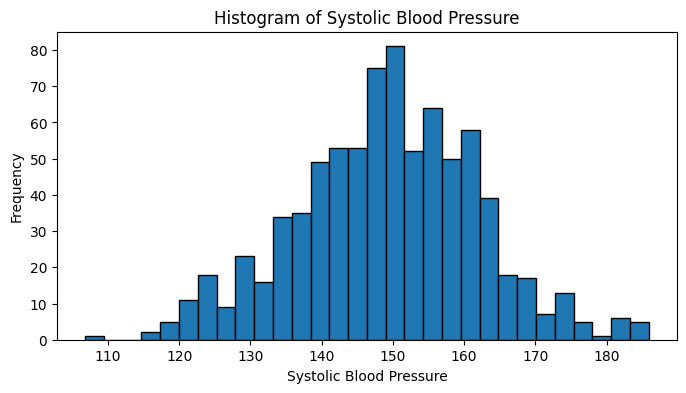

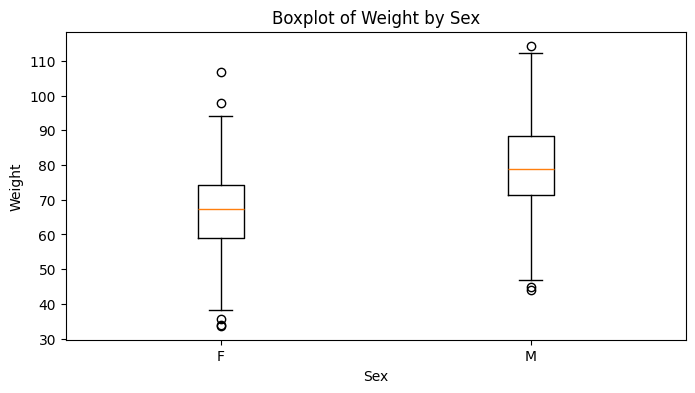

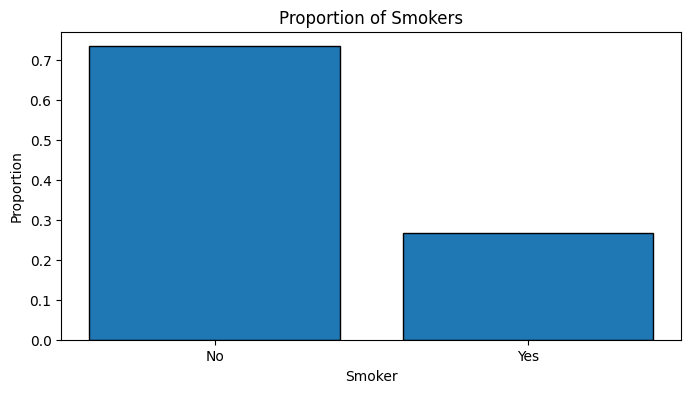

In [4]:
from src import plot_fig

plot_fig.hist_bloodpresure(df)
plot_fig.box_weight_sex(df)
plot_fig.bar_smokers(df)

In [7]:
np.random.seed(123)

disease_prop = df["disease"].mean()

sim_disease = np.random.binomial(n=1, p=disease_prop, size=1000)

sim_prop = sim_disease.mean()

print(f"Verklig andel: {disease_prop:.3f}")
print(f"Simulerad andel: {sim_prop:.3f}")
print(f"Skillnad: {abs(disease_prop - sim_prop):.3f}")



Verklig andel: 0.059
Simulerad andel: 0.066
Skillnad: 0.007


t test confidens interval

In [5]:
import scipy.stats as stats
import math

sample_size = len(df["systolic_bp"])
sample = df["systolic_bp"].to_numpy()
sample_mean = sample.mean()
std = sample.std(ddof=1)
confidence = 0.95
alpha = 1 - 0.95 
degrees_of_freedom = sample_size - 1

t_critical = stats.t.ppf(1 - alpha / 2, degrees_of_freedom) 

sigma = std / math.sqrt(sample_size)

me = t_critical * sigma 

t_low = sample_mean - me
t_high = sample_mean + me

print(t_low, t_high)

# stats.t.interval(0.95, df = sample_size - 1, loc=sample_mean, scale=sigma) kan också använda denna formeln för att räkna ut cl

148.29076170667028 150.06648829332974


Bootstrap confidens interval

In [6]:
import scipy.stats as stats
import math

rng = np.random.default_rng(123)

sample_size = len(df["systolic_bp"])
sample = df["systolic_bp"].to_numpy()
n_samples = 5000
boot_array = np.empty(n_samples)
for b in range(n_samples):
    boot_sample = rng.choice(sample, sample_size, replace=True)
    boot_array[b] = np.mean(boot_sample)


boot_low, boot_high = np.percentile(boot_array, [2.5, 97.5])

print(boot_low, boot_high)


148.3155625 150.04662812499998


skillnad mellan bootstrap och t test
Vi kan se att skillnaden är väldigt liten detta beror på till stor del att vårt urval är på 800 och att vi itererar 5000 med bootstrap. Med 800 element göra t t testet närmar sig normal distrubution
(vi hade kunnat använda oss av z score istället).

In [7]:
low = abs(t_low - boot_low)
high = abs(t_high - boot_high)

print(low, high)

0.024800793329717408 0.01986016832975679


In [8]:
from scipy.stats import ttest_ind

smokers = df[df["smoker"] =="Yes"]["systolic_bp"]
none_smokers = df[df["smoker"] =="No"]["systolic_bp"]

# Welch’s t-test
t_stat, p_value = ttest_ind(smokers, none_smokers, equal_var=False, alternative="greater")


print("T-statistic:", t_stat)
print("one-sided p-value:", p_value)
print(smokers.mean(), none_smokers.mean())



T-statistic: 0.4503433193393224
one-sided p-value: 0.3263669371699499
149.524882629108 149.05298126064736


Testet ger ett p-värde på 0.326, viket innebär att det är ungefär 33% chans att vi ser prov som har sådan här skillnad eller mer.
Jag använde mig av ett 95% konfidensintervall viket betyder att jag misslykades att avvisa noll_hypotesen efersom p värdet var större än alpha 0.05.
Det finns inte tillräckligt med stöd för att säga att det finns en skillnad.

In [10]:
import pingouin as pg
from statsmodels.stats.power import TTestIndPower

smokers = df[df["smoker"] =="Yes"]["systolic_bp"]
none_smokers = df[df["smoker"] =="No"]["systolic_bp"]


d = pg.compute_effsize(smokers, none_smokers, eftype="cohen") # detta räknar ut avståndet mellan två medelvärden i antal standardavikelser

analysis = TTestIndPower()

n1 = len(smokers)
n2 = len(none_smokers)

ratio = n2 / n1

power = analysis.power(effect_size=d, nobs1=n1 ,alpha = 0.05, ratio=ratio)

print(power)
print(d)


0.07461138937273196
0.03686824466352876


som vi kan se har jag bara en 7.5% chans att upptäcka en skillnad i systolic BP mellan rökare och ickerökare. Man brukar sätta gränsen vid 80% power viket vi ligger långt under 

In [11]:

smokers = df[df["smoker"] =="Yes"]["systolic_bp"]
none_smokers = df[df["smoker"] =="No"]["systolic_bp"]


andel_smokers = len(smokers) / len(df)
andel_none_smokers = len(none_smokers) / len(df)

print(andel_smokers, andel_none_smokers)

0.26625 0.73375


In [13]:
import pandas as pd
import numpy as np
from scipy import stats



# 2. Plocka ut systoliskt blodtryck för rökare och icke-rökare
smokers = df[df["smoker"] == "Yes"]["systolic_bp"].dropna().values
nonsmokers = df[df["smoker"] == "No"]["systolic_bp"].dropna().values

# Storlekar och varians i respektive grupp
n_s  = len(smokers)
n_ns = len(nonsmokers)
var_s  = np.var(smokers, ddof=1)
var_ns = np.var(nonsmokers, ddof=1)

print("Antal rökare:", n_s)
print("Antal icke-rökare:", n_ns)

# 3. Funktion för att skatta power med Monte Carlo-simulering
def estimate_power(effect_mmHg, iters=2000, alpha=0.05):
    """
    effect_mmHg = antagen sann skillnad i medel-BP (rökare - icke-rökare)
    iters       = antal simulerade studier
    alpha       = signifikansnivå
    """
    rng = np.random.default_rng()
    sig = 0
    base_mean = np.mean(nonsmokers)  # "sann" medel-BP för icke-rökare

    for _ in range(iters):
        # simulera data under H1: rökare har högre medel-BP
        sim_ns = rng.normal(loc=base_mean,              scale=np.sqrt(var_ns), size=n_ns)
        sim_s  = rng.normal(loc=base_mean + effect_mmHg, scale=np.sqrt(var_s),  size=n_s)

        # samma test som i din analys: tvåstickprov t-test (Welch)
        t_stat, p_val = stats.ttest_ind(sim_s, sim_ns, equal_var=False)

        if p_val < alpha:
            sig += 1

    # andel gånger vi blev signifikanta ≈ power
    return sig / iters

# 4. Testa några olika sanna skillnader
effects = [0, 1, 2, 3, 4, 5]  # mmHg
powers = [estimate_power(e) for e in effects]

for e, p in zip(effects, powers):
    print(f"Sann skillnad = {e:>2} mmHg  ->  power ≈ {p:.3f}")

Antal rökare: 213
Antal icke-rökare: 587
Sann skillnad =  0 mmHg  ->  power ≈ 0.045
Sann skillnad =  1 mmHg  ->  power ≈ 0.170
Sann skillnad =  2 mmHg  ->  power ≈ 0.456
Sann skillnad =  3 mmHg  ->  power ≈ 0.817
Sann skillnad =  4 mmHg  ->  power ≈ 0.970
Sann skillnad =  5 mmHg  ->  power ≈ 0.997


Vi börjar med att definiera två normalfördelningar som representerar de två populationerna (t.ex. rökare och icke-rökare), där båda har sina respektive standardavvikelser från den riktiga datan. Den ena populationen har ett medelvärde som är 3 mmHg högre än den andra för att motsvara den antagna sanna effekten.
Från dessa två fördelningar drar vi sedan slumpmässiga stickprov av storlek n och genomför ett Welch’s tvåstickprovstest (ttest_ind med equal_var=False). För varje iteration får vi ett t-värde och ett p-värde.
Denna process upprepas 2000 gånger. Efteråt räknar vi hur stor andel av simuleringarna som ger ett p-värde under 0,05, vilket innebär att nollhypotesen (ingen skillnad mellan grupperna) förkastas. Denna andel är en uppskattning av testets power, det vill säga sannolikheten att upptäcka en verklig skillnad på 3 mmHg givet stickprovsstorlekarna och variansen i datan.
I våra simuleringar ser vi att en sann skillnad på 3 mmHg skulle ge en power på cirka 80 %, vilket ofta används som en riktlinje för att en studie ska ha tillräcklig styrka för att kunna påvisa en effekt och därmed kunna förkasta nollhypotesen.

I vårt faktiska datamaterial uppskattas däremot powern till endast omkring 3,7 %. Detta är mycket lågt och innebär att studien har liten sannolikhet att upptäcka en eventuell verklig skillnad. Vi kan därför inte förkasta nollhypotesen, och den observerade skillnaden kan mycket väl bero på slumpen.